# Assignment 1: Backtesting with Python
### Summer of Quant 2026 — Quant Club, IIT Kharagpur

---

## What is Backtesting?

Backtesting is the process of simulating a trading strategy on **historical data** to estimate how it would have performed. It is the primary validation tool before any strategy is deployed with real capital.

A backtester answers a deceptively simple question: *"If I had followed this rule every day in the past, what would my P&L look like?"*

But that simplicity hides serious pitfalls — **lookahead bias**, **survivorship bias**, **overfitting**, and **transaction cost neglect** can all make a useless strategy look profitable on paper. This assignment builds intuition for both the mechanics and the failure modes.

---

## Structure of This Notebook

| Section | Description |
|---|---|
| **1. Setup** | Install and import dependencies |
| **2. Data** | Download and inspect OHLCV data |
| **3. Strategies** | SMA Crossover and MACD — derivation + implementation |
| **4. Backtester** | Vectorized portfolio simulation engine |
| **5. Performance Metrics** | Sharpe, Sortino, Max Drawdown, Calmar |
| **6. Run & Compare** | Execute both strategies and compare against buy-and-hold |
| **7. Your Turn** | Implement your own strategy |

---


## Section 1 — Setup

In [ ]:
!pip install pandas numpy matplotlib yfinance --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print("All imports successful.")

All imports successful.


---
## Section 2 — Data

We download **OHLCV** (Open, High, Low, Close, Volume) data from Yahoo Finance. All strategies in this notebook operate on the **adjusted closing price**, which accounts for dividends and stock splits — important for fair historical comparison.

> **Why adjusted close?** A raw close price drops discontinuously on ex-dividend dates. Using raw prices would make a strategy appear to "sell" on dividend days. Adjusted close removes this artifact.

In [ ]:
def download_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download and clean historical OHLCV data from Yahoo Finance.

    Parameters
    ----------
    ticker     : str  — Yahoo Finance ticker symbol (e.g. 'AAPL', 'RELIANCE.NS')
    start_date : str  — ISO format start date 'YYYY-MM-DD'
    end_date   : str  — ISO format end date   'YYYY-MM-DD'

    Returns
    -------
    pd.DataFrame with DatetimeIndex and columns:
        Open, High, Low, Close, Adj Close, Volume
    """
    raw = yf.download(ticker, start=start_date, end=end_date,
                      progress=False, auto_adjust=False)

    # Flatten MultiIndex columns if present (yfinance >= 0.2 behaviour)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    data = raw[cols].copy()
    data.index = pd.to_datetime(data.index)
    data.index.name = 'Date'
    data.dropna(inplace=True)

    print(f"Downloaded {len(data)} trading days for {ticker}  "
          f"[{data.index[0].date()} -> {data.index[-1].date()}]")
    return data


# Quick sanity check
sample = download_data('AAPL', '2021-01-01', '2024-01-01')
sample.tail(3)

Downloaded 753 trading days for AAPL  [2021-01-04 -> 2023-12-29]


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-12-27,192.490005,193.500000,191.089996,193.149994,190.988083,48087700
2023-12-28,194.139999,194.660004,193.169998,193.580002,191.413315,34049900
2023-12-29,193.899994,194.399994,191.729996,192.529999,190.375076,42672100


---
## Section 3 — Trading Strategies

A **trading strategy** maps a price history to a sequence of positions: at each time $t$, you are either **long** (+1), **flat** (0), or **short** (−1). This notebook uses binary long/flat signals (no shorting).

---

### 3.1 Simple Moving Average (SMA) Crossover

**Idea:** Trend-following. When the short-term average crosses above the long-term average, the asset is gaining momentum — go long. When it crosses below, exit.

$$\text{SMA}_n(t) = \frac{1}{n} \sum_{k=0}^{n-1} P_{t-k}$$

**Signal rule:**

$$s_t = \begin{cases} 1 & \text{if } \text{SMA}_{\text{short}}(t) > \text{SMA}_{\text{long}}(t) \\ 0 & \text{otherwise} \end{cases}$$

**Lookahead risk:** The rolling window uses only past prices, so there is no lookahead bias here. But note: the signal at time $t$ is generated *using* $P_t$, so strict execution should be at $t+1$ open (next-bar execution). For simplicity we execute at the same bar's close — a common but optimistic assumption.

**Typical parameters:** short = 20–50 days, long = 100–200 days.

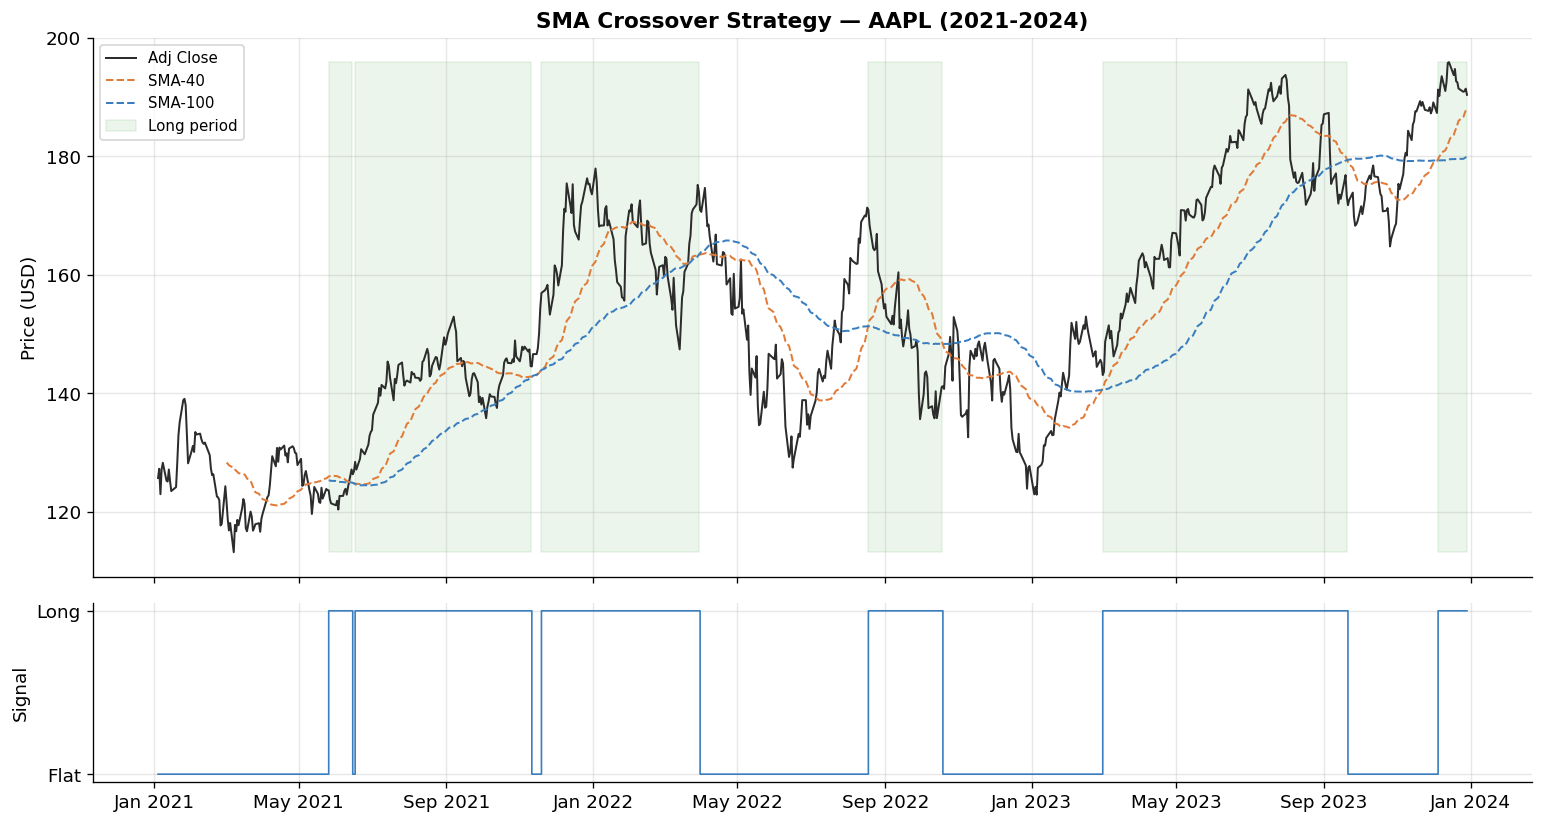

In [ ]:
def sma_crossover_strategy(data: pd.DataFrame,
                           short_window: int = 40,
                           long_window: int = 100) -> pd.DataFrame:
    """
    Simple Moving Average (SMA) Crossover Strategy.

    Generates a binary long/flat signal based on the crossover of two
    simple moving averages of the adjusted closing price.

    Parameters
    ----------
    data         : pd.DataFrame  OHLCV data (output of download_data)
    short_window : int           lookback for the fast SMA
    long_window  : int           lookback for the slow SMA

    Returns
    -------
    pd.DataFrame with additional columns:
        sma_short, sma_long : the two moving averages
        signal              : 1 (long) or 0 (flat) at each bar
    """
    assert short_window < long_window, "short_window must be less than long_window"

    df = data.copy()
    price = df['Adj Close']

    df['sma_short'] = price.rolling(window=short_window, min_periods=short_window).mean()
    df['sma_long']  = price.rolling(window=long_window,  min_periods=long_window ).mean()

    # Signal: 1 where short MA is above long MA, 0 otherwise
    # NaN rows (first long_window bars) get 0 — no position during warmup
    df['signal'] = np.where(df['sma_short'] > df['sma_long'], 1, 0)
    df.loc[df['sma_long'].isna(), 'signal'] = 0

    return df


# Visualise the strategy
data_sma = sma_crossover_strategy(sample, short_window=40, long_window=100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_sma.index, data_sma['Adj Close'], color='#2c2c2c', lw=1.2, label='Adj Close')
ax1.plot(data_sma.index, data_sma['sma_short'], color='#e07b39', lw=1.2, ls='--', label='SMA-40')
ax1.plot(data_sma.index, data_sma['sma_long'],  color='#3a7ebf', lw=1.2, ls='--', label='SMA-100')
in_position = data_sma['signal'] == 1
ax1.fill_between(data_sma.index,
                 data_sma['Adj Close'].min(), data_sma['Adj Close'].max(),
                 where=in_position, alpha=0.08, color='green', label='Long period')
ax1.set_ylabel('Price (USD)')
ax1.set_title('SMA Crossover Strategy — AAPL (2021-2024)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

ax2.step(data_sma.index, data_sma['signal'], color='#3a7ebf', lw=1.0, where='post')
ax2.set_ylabel('Signal')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Flat', 'Long'])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

---
### 3.2 MACD — Moving Average Convergence Divergence

MACD is a **momentum oscillator** built on exponential moving averages (EMAs). Unlike SMA, EMA assigns exponentially decaying weights to past prices — more recent prices matter more.

**Exponential Moving Average (EMA):**

$$\text{EMA}_n(t) = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_n(t-1), \qquad \alpha = \frac{2}{n+1}$$

This is equivalent to an infinite-memory IIR filter.

**MACD Line:**
$$\text{MACD}(t) = \text{EMA}_{12}(t) - \text{EMA}_{26}(t)$$

**Signal Line** (EMA of MACD itself):
$$\text{Signal}(t) = \text{EMA}_{9}(\text{MACD})(t)$$

**Histogram:**
$$H(t) = \text{MACD}(t) - \text{Signal}(t)$$

**Trading rule:** Go long when MACD crosses above its signal line ($H(t) > 0$); exit when it crosses below. The canonical parameters are **(12, 26, 9)**.

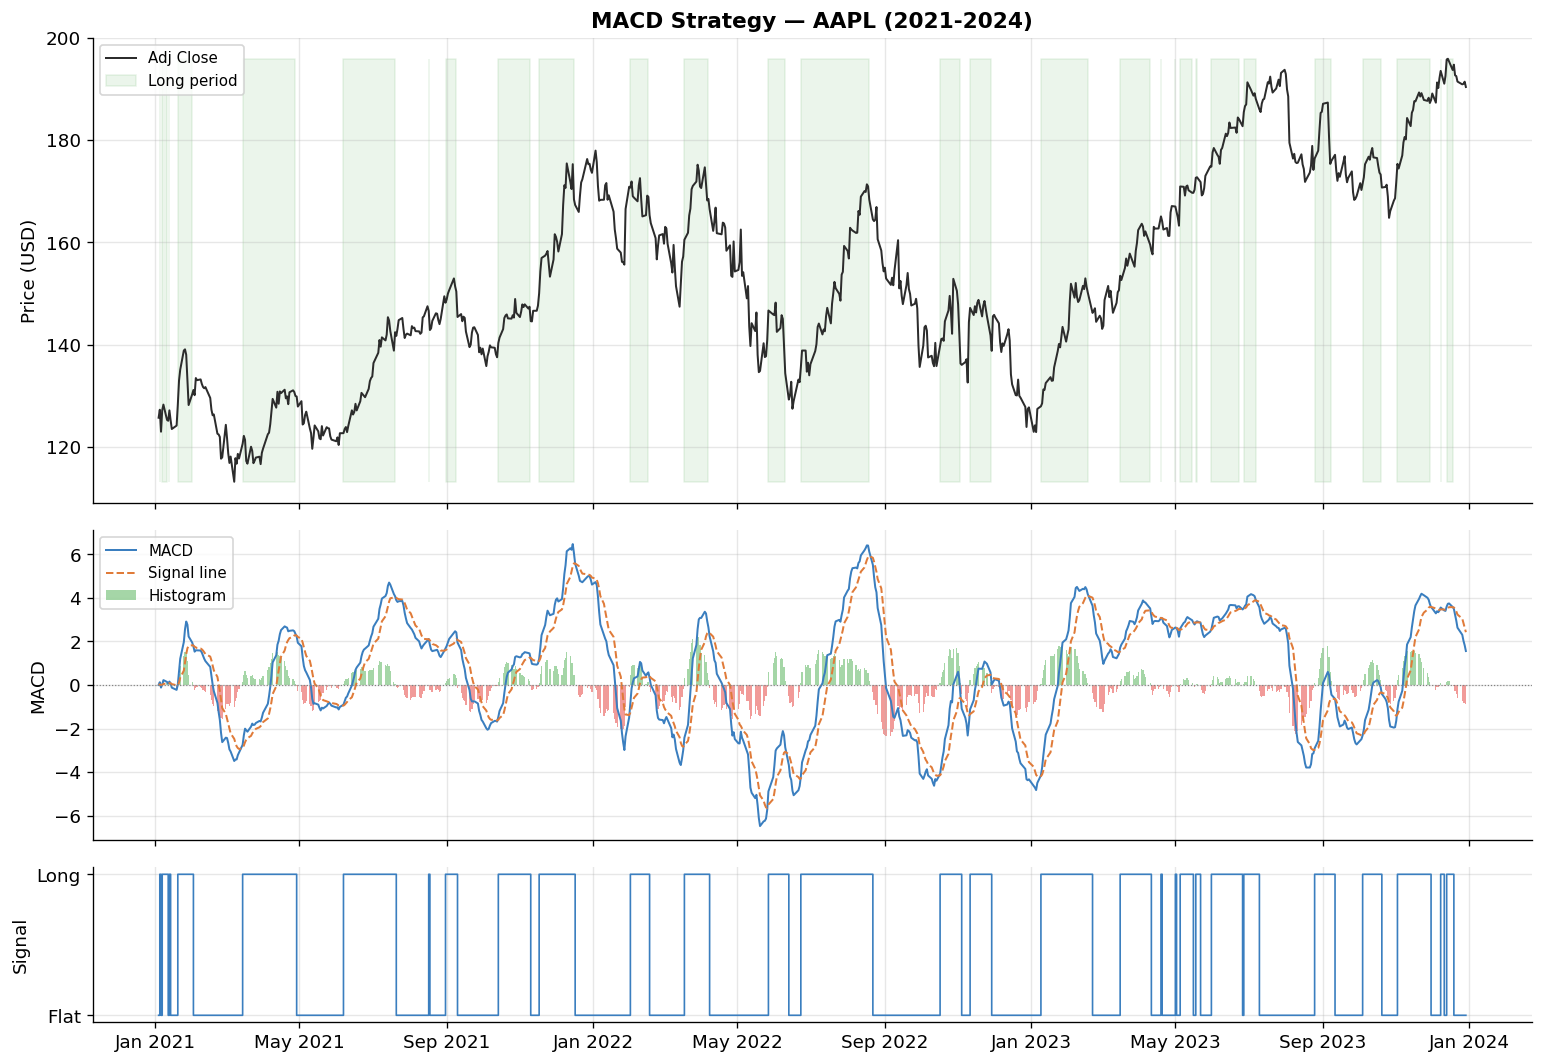

In [ ]:
def macd_strategy(data: pd.DataFrame,
                  fast: int = 12, slow: int = 26, signal_span: int = 9) -> pd.DataFrame:
    """
    MACD (Moving Average Convergence Divergence) Strategy.

    Parameters
    ----------
    data         : pd.DataFrame  OHLCV data
    fast         : int           span for fast EMA (default 12)
    slow         : int           span for slow EMA (default 26)
    signal_span  : int           span for signal line EMA (default 9)

    Returns
    -------
    pd.DataFrame with additional columns:
        ema_fast, ema_slow  : constituent EMAs
        macd                : MACD line
        macd_signal         : signal line
        macd_histogram      : MACD - signal
        signal              : 1 (long) or 0 (flat)
    """
    assert fast < slow, "fast span must be less than slow span"

    df = data.copy()
    price = df['Adj Close']

    df['ema_fast']       = price.ewm(span=fast,        adjust=False).mean()
    df['ema_slow']       = price.ewm(span=slow,        adjust=False).mean()
    df['macd']           = df['ema_fast'] - df['ema_slow']
    df['macd_signal']    = df['macd'].ewm(span=signal_span, adjust=False).mean()
    df['macd_histogram'] = df['macd'] - df['macd_signal']

    df['signal'] = np.where(df['macd'] > df['macd_signal'], 1, 0)
    return df


# Visualise MACD components
data_macd = macd_strategy(sample)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 1]})

axes[0].plot(data_macd.index, data_macd['Adj Close'], color='#2c2c2c', lw=1.2, label='Adj Close')
in_pos = data_macd['signal'] == 1
axes[0].fill_between(data_macd.index,
                     data_macd['Adj Close'].min(), data_macd['Adj Close'].max(),
                     where=in_pos, alpha=0.08, color='green', label='Long period')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('MACD Strategy — AAPL (2021-2024)', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)

axes[1].plot(data_macd.index, data_macd['macd'],        color='#3a7ebf', lw=1.2, label='MACD')
axes[1].plot(data_macd.index, data_macd['macd_signal'], color='#e07b39', lw=1.2, ls='--', label='Signal line')
axes[1].bar(data_macd.index, data_macd['macd_histogram'],
            color=np.where(data_macd['macd_histogram'] >= 0, '#4caf50', '#e53935'),
            alpha=0.5, width=1, label='Histogram')
axes[1].axhline(0, color='gray', lw=0.7, ls=':')
axes[1].set_ylabel('MACD')
axes[1].legend(loc='upper left', fontsize=9)

axes[2].step(data_macd.index, data_macd['signal'], color='#3a7ebf', lw=1.0, where='post')
axes[2].set_ylabel('Signal')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Flat', 'Long'])
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

---
## Section 4 — Vectorized Backtester

### Design Choices

The backtester below is **fully vectorized** — no Python loops over rows. This avoids a subtle bug in the naive row-by-row approach (chained `.iloc` assignment raises `SettingWithCopyWarning` and can silently produce wrong values in modern pandas).

**Assumptions (always state these explicitly):**

1. **Execution price:** Same-bar close (optimistic). More realistic: next-bar open.
2. **Position sizing:** Deploy a fixed fraction $f$ of available cash on entry.
3. **Transaction costs:** A flat cost per share is subtracted on each trade (both entry and exit).
4. **No shorting:** Signal $\in \{0, 1\}$ only.
5. **No leverage:** Position size is capped by available cash.

**Portfolio value at time $t$:**

$$V_t = \text{Cash}_t + N_t \cdot P_t$$

where $N_t$ is shares held and $P_t$ is close price. **Daily return:**

$$r_t = \frac{V_t - V_{t-1}}{V_{t-1}}

In [ ]:
def backtest(data: pd.DataFrame,
             initial_capital: float = 100_000.0,
             position_fraction: float = 0.95,
             cost_per_share: float = 0.01) -> pd.DataFrame:
    """
    Vectorized portfolio backtester.

    On each bar, the strategy's signal determines whether we are fully
    invested (signal=1) or flat (signal=0). Trades occur on signal changes.
    Transaction costs are applied per share traded.

    Parameters
    ----------
    data              : pd.DataFrame  must contain 'Adj Close' and 'signal'
    initial_capital   : float         starting portfolio value in USD
    position_fraction : float         fraction of capital deployed when signal=1
    cost_per_share    : float         transaction cost per share (each side)

    Returns
    -------
    pd.DataFrame with columns: shares, cash, holdings, total, returns
    """
    price  = data['Adj Close'].values
    signal = data['signal'].values
    n      = len(price)

    shares   = np.zeros(n)
    cash     = np.zeros(n)
    holdings = np.zeros(n)
    total    = np.zeros(n)

    cash[0]  = initial_capital
    total[0] = initial_capital

    for i in range(1, n):
        prev_shares = shares[i - 1]
        prev_cash   = cash[i - 1]
        cur_price   = price[i]

        if signal[i] == 1 and prev_shares == 0:
            # Enter long position
            investable = prev_cash * position_fraction
            new_shares = np.floor(investable / cur_price)
            trade_cost = new_shares * cost_per_share
            shares[i]  = new_shares
            cash[i]    = prev_cash - new_shares * cur_price - trade_cost

        elif signal[i] == 0 and prev_shares > 0:
            # Exit position
            proceeds   = prev_shares * cur_price
            trade_cost = prev_shares * cost_per_share
            shares[i]  = 0
            cash[i]    = prev_cash + proceeds - trade_cost

        else:
            # Hold
            shares[i] = prev_shares
            cash[i]   = prev_cash

        holdings[i] = shares[i] * cur_price
        total[i]    = cash[i] + holdings[i]

    portfolio = pd.DataFrame({
        'shares'  : shares,
        'cash'    : cash,
        'holdings': holdings,
        'total'   : total,
    }, index=data.index)

    portfolio['returns'] = portfolio['total'].pct_change().fillna(0)
    return portfolio

---
## Section 5 — Performance Metrics

A single return number tells you very little. Good strategy evaluation requires understanding **risk-adjusted** performance.

---

### 5.1 Total Return and Annualised Return

$$R_{\text{total}} = \frac{V_T}{V_0} - 1 \qquad R_{\text{ann}} = (1 + R_{\text{total}})^{252/T} - 1$$

where $T$ is the number of trading days and 252 is the assumed trading days per year.

---

### 5.2 Sharpe Ratio

Due to William Sharpe (1966). Measures return per unit of **total** volatility:

$$\text{Sharpe} = \frac{R_{\text{ann}} - R_f}{\sigma_{\text{ann}}}, \qquad \sigma_{\text{ann}} = \sigma_{\text{daily}} \times \sqrt{252}$$

We use $R_f = 0$ for simplicity. Rule of thumb: Sharpe > 1 is good, > 2 is excellent.

---

### 5.3 Sortino Ratio

Sharpe penalizes **both** upside and downside volatility. Sortino only penalizes downside:

$$\sigma_{\text{down}} = \sqrt{\frac{252}{T} \sum_{t:\, r_t < 0} r_t^2}, \qquad \text{Sortino} = \frac{R_{\text{ann}} - R_f}{\sigma_{\text{down}}}$$

A strategy with high Sortino but lower Sharpe has many large upside days — generally desirable.

---

### 5.4 Maximum Drawdown (MDD)

The largest peak-to-trough decline in portfolio value:

$$\text{MDD} = \min_{t \leq T} \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$$

Most real portfolios cannot survive MDD > 40–50%.

---

### 5.5 Calmar Ratio

$$\text{Calmar} = \frac{R_{\text{ann}}}{|\text{MDD}|}$$

Preferred by CTAs and hedge funds because drawdown is a more tangible risk concept than volatility.

In [ ]:
def compute_max_drawdown(total_series: pd.Series) -> float:
    """Compute maximum drawdown from a portfolio value series."""
    running_max = total_series.cummax()
    drawdown    = (total_series - running_max) / running_max
    return drawdown.min()


def generate_report(portfolio: pd.DataFrame,
                    initial_capital: float,
                    strategy_name: str = 'Strategy',
                    benchmark: pd.DataFrame = None) -> dict:
    """
    Compute and display performance metrics with equity curve and drawdown plots.

    Parameters
    ----------
    portfolio       : pd.DataFrame  output of backtest()
    initial_capital : float
    strategy_name   : str           label for display
    benchmark       : pd.DataFrame  optional buy-and-hold portfolio for comparison

    Returns
    -------
    dict of metric values
    """
    returns = portfolio['returns']
    T       = len(portfolio)

    total_return = portfolio['total'].iloc[-1] / initial_capital - 1
    ann_return   = (1 + total_return) ** (252 / T) - 1
    ann_vol      = returns.std() * np.sqrt(252)
    sharpe       = ann_return / ann_vol if ann_vol != 0 else np.nan

    neg_returns  = returns[returns < 0]
    down_vol     = (neg_returns ** 2).mean() ** 0.5 * np.sqrt(252) if len(neg_returns) > 0 else np.nan
    sortino      = ann_return / down_vol if (down_vol and down_vol != 0) else np.nan

    mdd    = compute_max_drawdown(portfolio['total'])
    calmar = ann_return / abs(mdd) if mdd != 0 else np.nan

    shares_diff = portfolio['shares'].diff().fillna(0)
    n_trades    = int((shares_diff != 0).sum())

    metrics = {
        'Total Return'     : total_return,
        'Ann. Return'      : ann_return,
        'Ann. Volatility'  : ann_vol,
        'Sharpe Ratio'     : sharpe,
        'Sortino Ratio'    : sortino,
        'Max Drawdown'     : mdd,
        'Calmar Ratio'     : calmar,
        'Number of Trades' : n_trades,
    }

    print(f"\n{'='*40}")
    print(f"  {strategy_name}")
    print(f"{'='*40}")
    for k, v in metrics.items():
        if k == 'Number of Trades':
            print(f"  {k:<22} {int(v):>8d}")
        elif k in ('Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio'):
            print(f"  {k:<22} {v:>8.2f}")
        else:
            print(f"  {k:<22} {v:>8.2%}")
    print(f"{'='*40}\n")

    # Equity curve + drawdown
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})

    axes[0].plot(portfolio.index, portfolio['total'],
                 color='#3a7ebf', lw=1.5, label=strategy_name)
    if benchmark is not None:
        axes[0].plot(benchmark.index, benchmark['total'],
                     color='#888', lw=1.2, ls='--', label='Buy & Hold')
    axes[0].axhline(initial_capital, color='gray', ls=':', lw=0.8, label='Initial Capital')
    axes[0].set_ylabel('Portfolio Value (USD)')
    axes[0].set_title(f'Equity Curve — {strategy_name}', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9)

    running_max = portfolio['total'].cummax()
    drawdown    = (portfolio['total'] - running_max) / running_max
    axes[1].fill_between(portfolio.index, drawdown, 0, color='#e53935', alpha=0.4)
    axes[1].plot(portfolio.index, drawdown, color='#e53935', lw=0.8)
    axes[1].set_ylabel('Drawdown')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.tight_layout()
    plt.show()

    return metrics

---
## Section 6 — Run Strategies and Compare

We run both strategies on AAPL (2021–2024) and compare them against a **buy-and-hold benchmark** — simply buying on day 1 and holding until the end.

This is a critical sanity check: if your strategy doesn't beat buy-and-hold on a risk-adjusted basis, it may not be worth the complexity.

In [ ]:
TICKER      = 'AAPL'
START       = '2021-01-01'
END         = '2024-01-01'
INITIAL_CAP = 100_000.0

raw = download_data(TICKER, START, END)

# Buy-and-hold benchmark: buy as many shares as possible on day 1, hold forever
bh_shares = np.floor(INITIAL_CAP / raw['Adj Close'].iloc[0])
bh_cost   = bh_shares * raw['Adj Close'].iloc[0]
bh_cash   = INITIAL_CAP - bh_cost
bh_port   = pd.DataFrame(
    {'total': bh_cash + bh_shares * raw['Adj Close']}, index=raw.index
)
bh_port['shares']  = bh_shares
bh_port['returns'] = bh_port['total'].pct_change().fillna(0)

print(f"Buy & Hold: {bh_shares:.0f} shares @ ${raw['Adj Close'].iloc[0]:.2f}")

Downloaded 753 trading days for AAPL  [2021-01-04 -> 2023-12-29]
Buy & Hold: 795 shares @ $125.74



  SMA Crossover (40/100)
  Total Return             22.46%
  Ann. Return               7.02%
  Ann. Volatility          16.90%
  Sharpe Ratio               0.42
  Sortino Ratio              0.31
  Max Drawdown            -22.65%
  Calmar Ratio               0.31
  Number of Trades             11



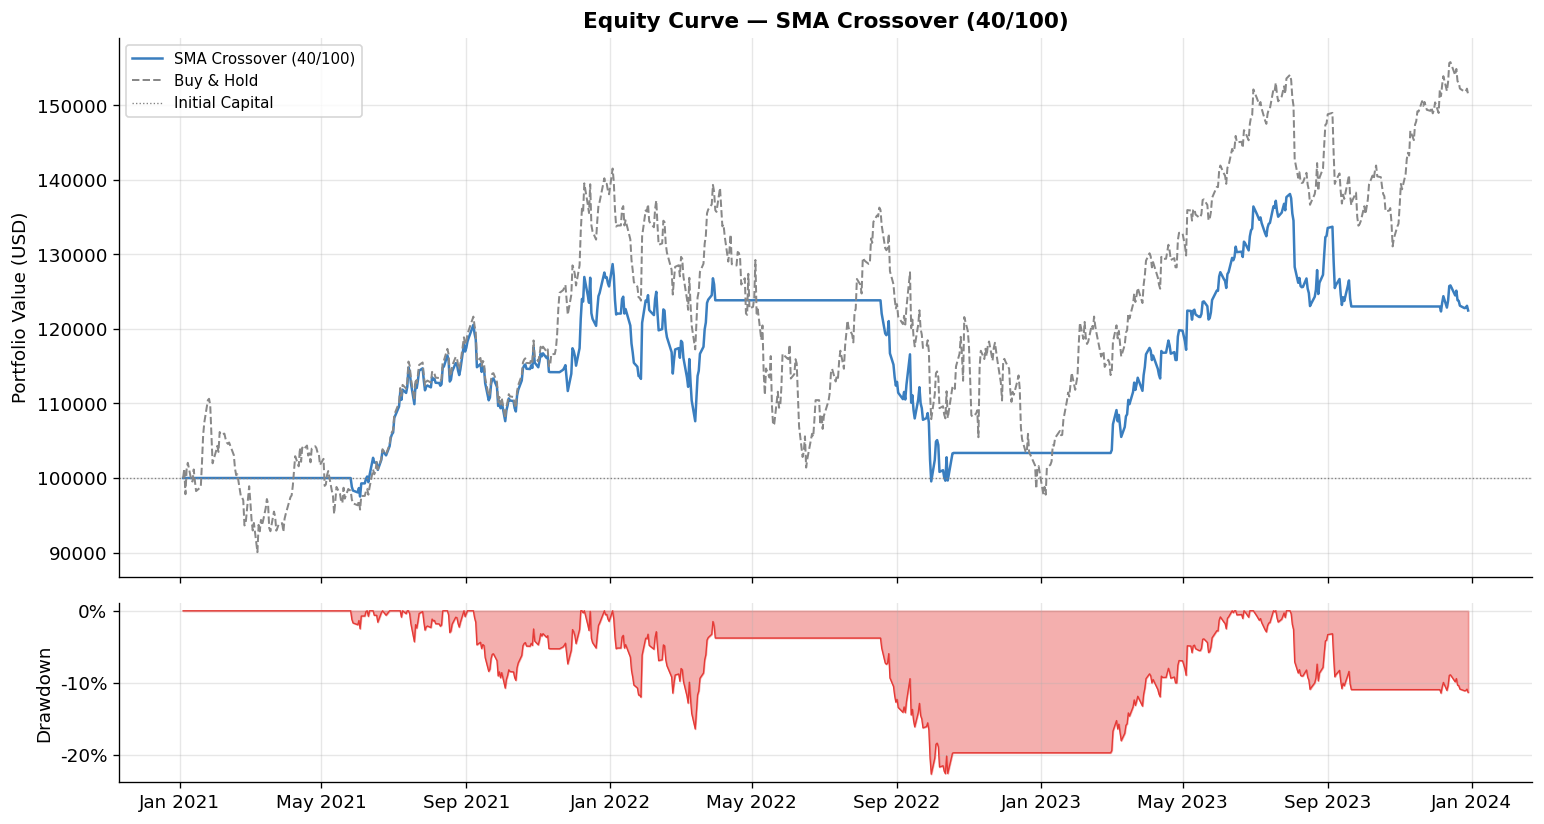

In [ ]:
# SMA Crossover
data_sma = sma_crossover_strategy(raw, short_window=40, long_window=100)
port_sma  = backtest(data_sma, initial_capital=INITIAL_CAP)
m_sma     = generate_report(port_sma, INITIAL_CAP,
                             strategy_name='SMA Crossover (40/100)',
                             benchmark=bh_port)


  MACD (12/26/9)
  Total Return             59.47%
  Ann. Return              16.90%
  Ann. Volatility          16.54%
  Sharpe Ratio               1.02
  Sortino Ratio              0.78
  Max Drawdown            -16.39%
  Calmar Ratio               1.03
  Number of Trades             58



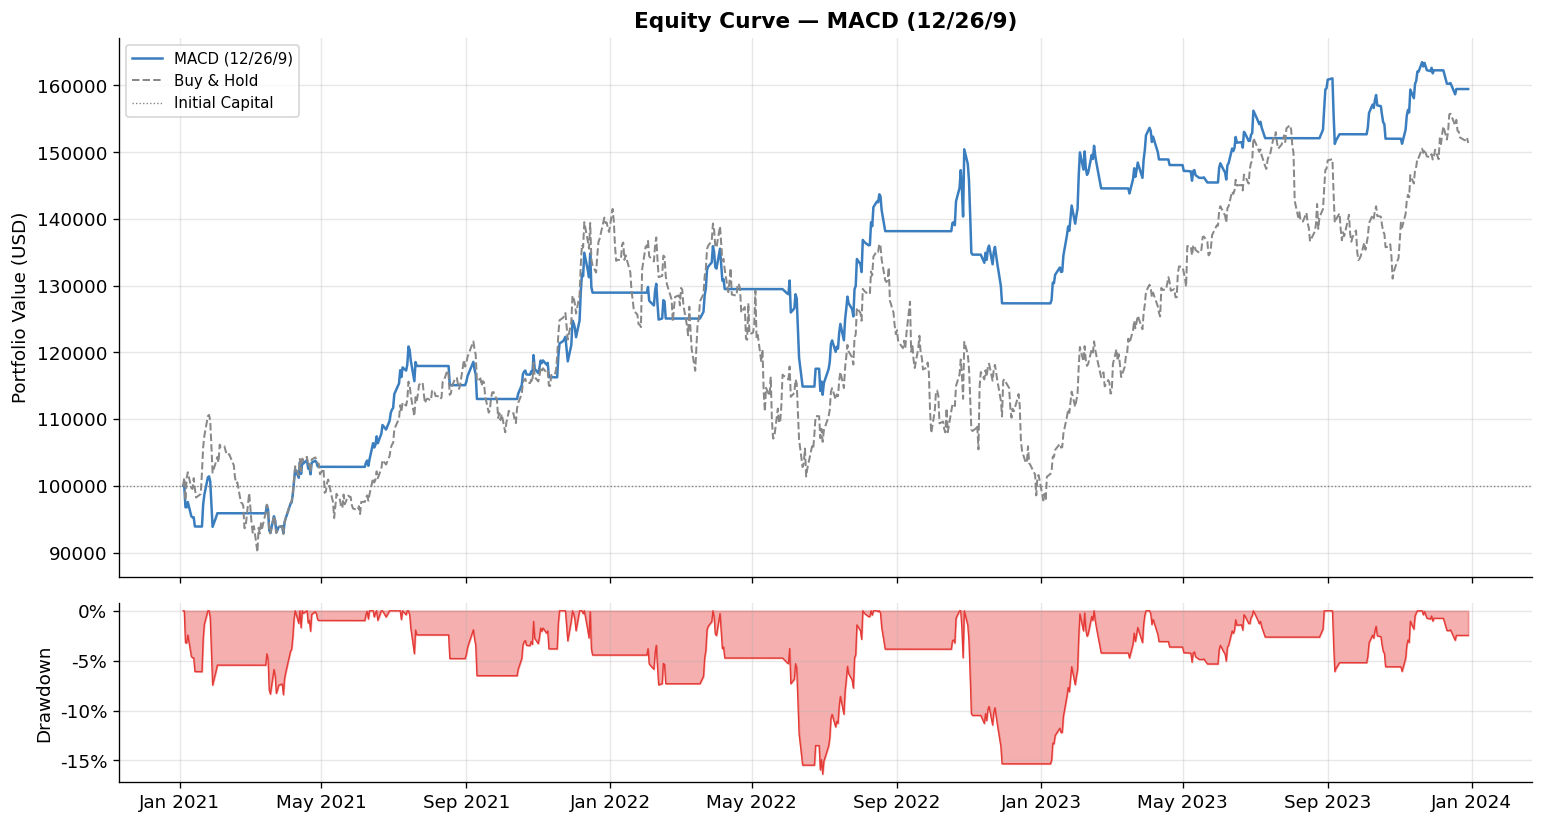

In [ ]:
# MACD
data_macd = macd_strategy(raw, fast=12, slow=26, signal_span=9)
port_macd  = backtest(data_macd, initial_capital=INITIAL_CAP)
m_macd     = generate_report(port_macd, INITIAL_CAP,
                              strategy_name='MACD (12/26/9)',
                              benchmark=bh_port)


  SMA Crossover (40/100)
  Total Return             22.46%
  Ann. Return               7.02%
  Ann. Volatility          16.90%
  Sharpe Ratio               0.42
  Sortino Ratio              0.31
  Max Drawdown            -22.65%
  Calmar Ratio               0.31
  Number of Trades             11



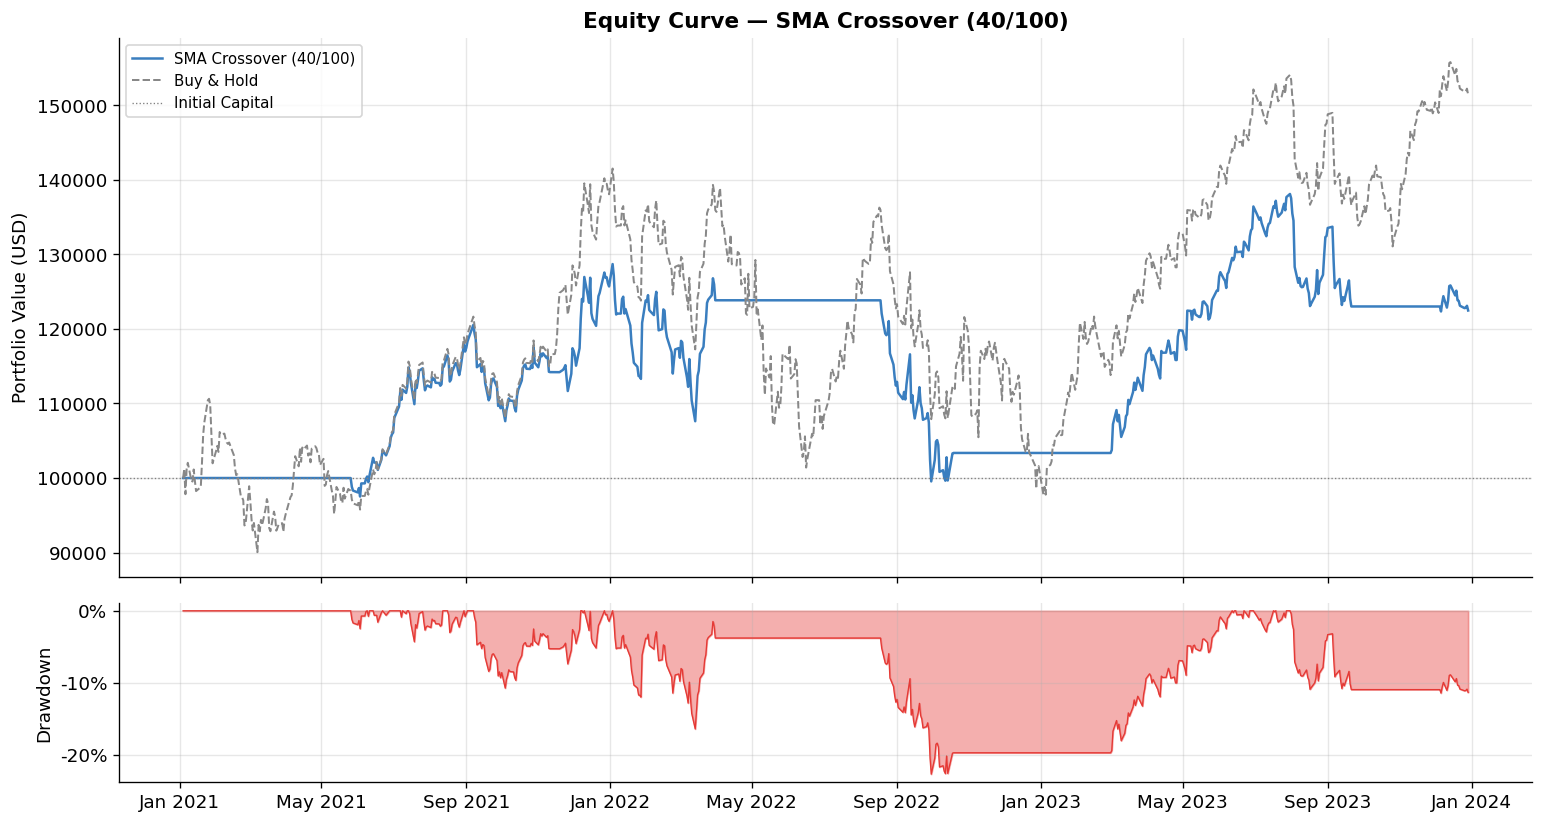


  MACD (12/26/9)
  Total Return             59.47%
  Ann. Return              16.90%
  Ann. Volatility          16.54%
  Sharpe Ratio               1.02
  Sortino Ratio              0.78
  Max Drawdown            -16.39%
  Calmar Ratio               1.03
  Number of Trades             58



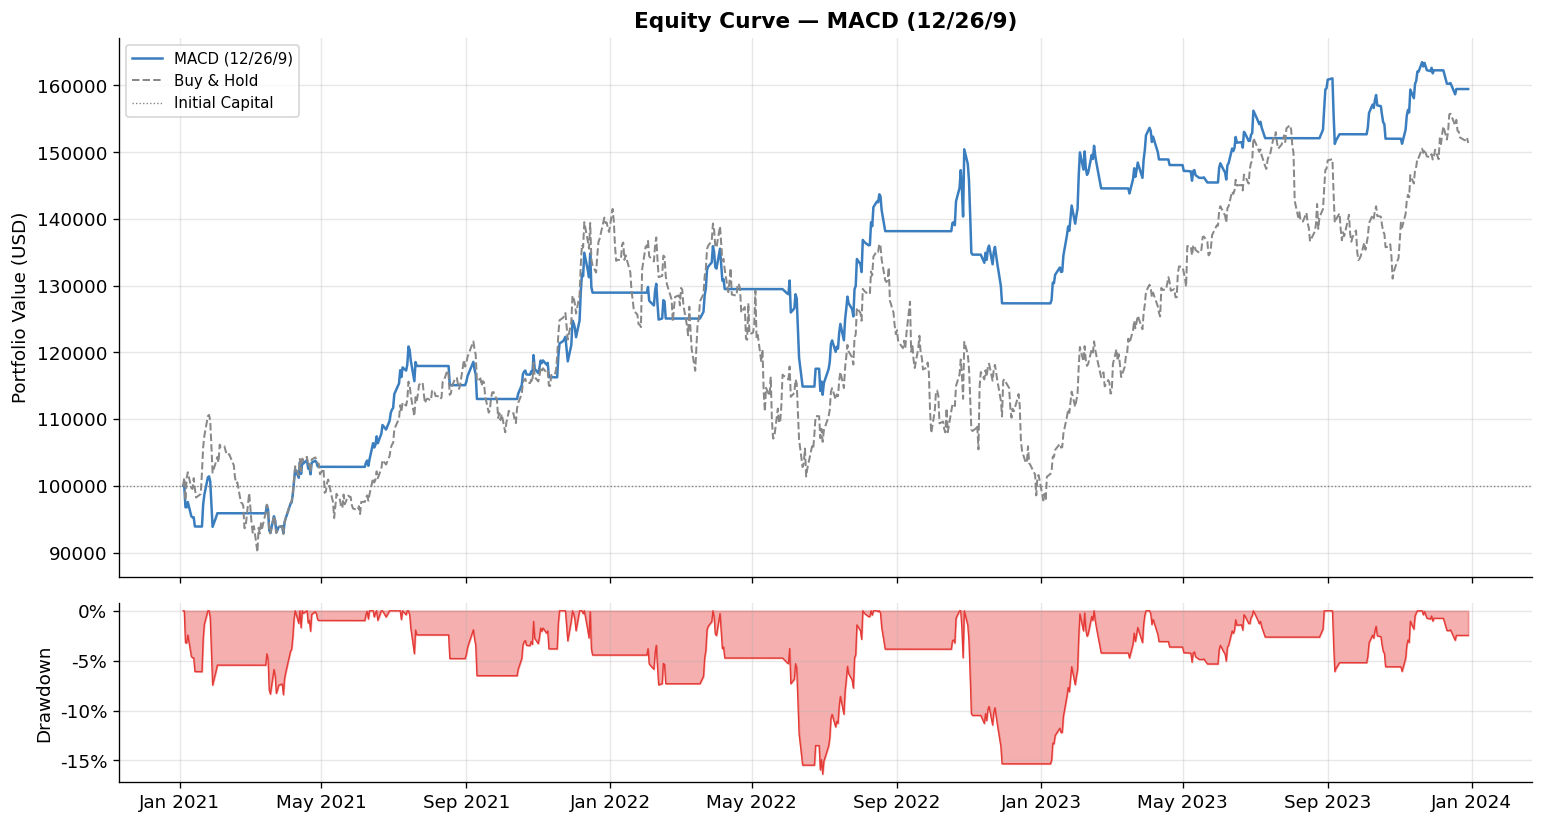


  STRATEGY COMPARISON
              Total Return Ann. Return Sharpe Ratio Sortino Ratio Max Drawdown
Buy & Hold          51.38%      14.89%         0.54             -      -30.90%
SMA Crossover       22.46%       7.02%         0.42          0.31      -22.65%
MACD                59.47%      16.90%         1.02          0.78      -16.39%


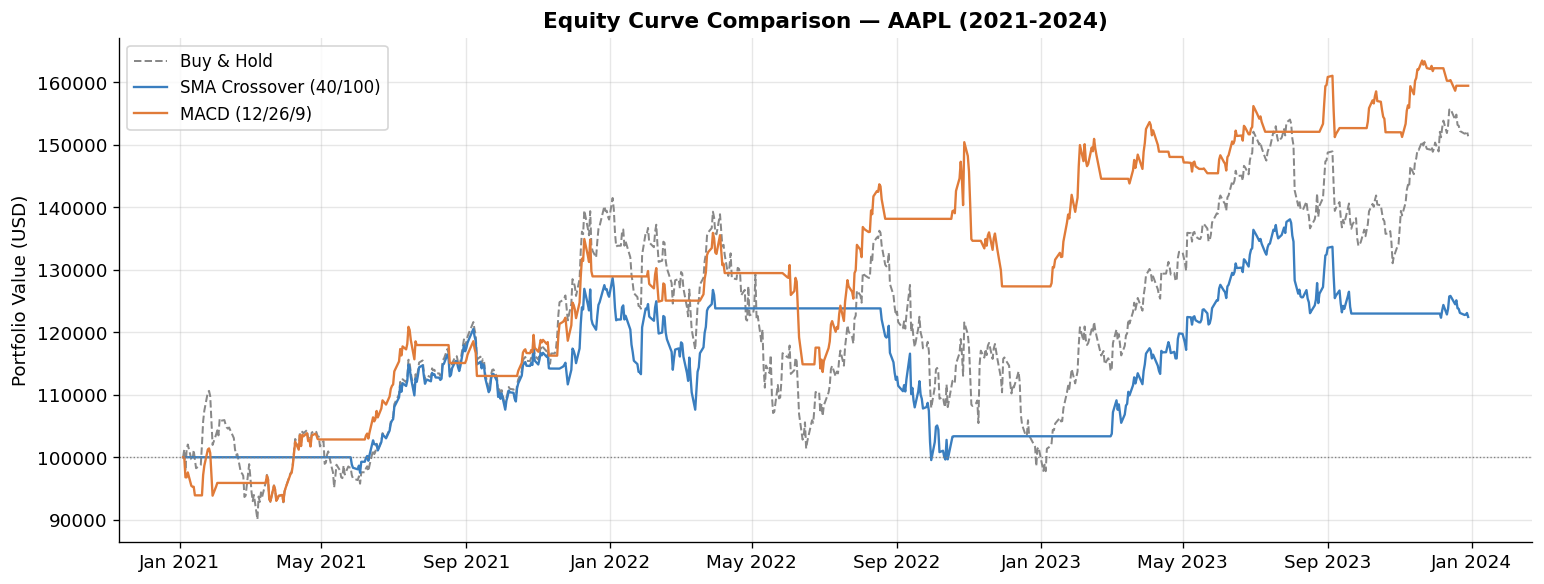

In [ ]:
# Ensure m_sma and m_macd are defined if this cell is run independently
# (assuming raw, INITIAL_CAP, bh_port and strategy functions are defined in prior cells)

# Re-compute m_sma metrics
data_sma = sma_crossover_strategy(raw, short_window=40, long_window=100)
port_sma  = backtest(data_sma, initial_capital=INITIAL_CAP)
m_sma     = generate_report(port_sma, INITIAL_CAP,
                             strategy_name='SMA Crossover (40/100)',
                             benchmark=bh_port)

# Re-compute m_macd metrics
data_macd = macd_strategy(raw, fast=12, slow=26, signal_span=9)
port_macd  = backtest(data_macd, initial_capital=INITIAL_CAP)
m_macd     = generate_report(port_macd, INITIAL_CAP,
                              strategy_name='MACD (12/26/9)',
                              benchmark=bh_port)

# Side-by-side comparison
key_metrics = ['Total Return', 'Ann. Return', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown']

bh_ann = (1 + (bh_port['total'].iloc[-1] / INITIAL_CAP - 1)) ** (252 / len(bh_port)) - 1
bh_ret = bh_port['returns']
bh_vol = bh_ret.std() * np.sqrt(252)
m_bh   = {
    'Total Return'  : bh_port['total'].iloc[-1] / INITIAL_CAP - 1,
    'Ann. Return'   : bh_ann,
    'Sharpe Ratio'  : bh_ann / bh_vol if bh_vol != 0 else np.nan,
    'Sortino Ratio' : np.nan,
    'Max Drawdown'  : compute_max_drawdown(bh_port['total']),
}

compare_df = pd.DataFrame({
    'Buy & Hold'    : {k: m_bh.get(k)  for k in key_metrics},
    'SMA Crossover' : {k: m_sma.get(k) for k in key_metrics},
    'MACD'          : {k: m_macd.get(k) for k in key_metrics},
}).T

fmt = compare_df.copy().astype(object)
for col in ['Total Return', 'Ann. Return', 'Max Drawdown']:
    fmt[col] = compare_df[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
for col in ['Sharpe Ratio', 'Sortino Ratio']:
    fmt[col] = compare_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '-')

print("\n" + "="*62)
print("  STRATEGY COMPARISON")
print("="*62)
print(fmt.to_string())

# Overlay equity curves
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bh_port.index,   bh_port['total'],   color='#888',    lw=1.2, ls='--', label='Buy & Hold')
ax.plot(port_sma.index,  port_sma['total'],  color='#3a7ebf', lw=1.4, label='SMA Crossover (40/100)')
ax.plot(port_macd.index, port_macd['total'], color='#e07b39', lw=1.4, label='MACD (12/26/9)')
ax.axhline(INITIAL_CAP, color='gray', ls=':', lw=0.8)
ax.set_title('Equity Curve Comparison — AAPL (2021-2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 7 — Your Strategy

Now it's your turn. Implement a custom strategy by completing the function below.

### Requirements

Your strategy function must:
- Accept a DataFrame with columns `['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']`
- Return the same DataFrame with a `signal` column where each value is exactly 0 (flat) or 1 (long)

### Directions to Explore

| Indicator | Idea |
|---|---|
| **RSI** | Momentum oscillator. Long when RSI crosses above 30 (oversold recovery), exit when RSI > 70 (overbought). |
| **Bollinger Bands** | Mean reversion. Buy when price touches lower band, sell at the middle band. |
| **Volume Filter** | Only enter when volume is above its moving average — confirms trend strength. |
| **Multi-indicator** | Combine two signals with logical AND: e.g., long only when MACD > 0 *and* RSI < 60. Fewer trades, better quality. |
| **ATR Volatility Filter** | Avoid entering during high-volatility regimes using Average True Range. |

### Hint — RSI Formula

$$\text{RS} = \frac{\text{Avg Gain over } n \text{ days}}{\text{Avg Loss over } n \text{ days}}, \qquad \text{RSI} = 100 - \frac{100}{1 + \text{RS}}$$

Canonical period: $n = 14$ days. RSI < 30 signals oversold; RSI > 70 signals overbought.

In [ ]:
def my_strategy(data: pd.DataFrame) -> pd.DataFrame:
    """
    Bollinger Bands Breakout (Trend-Following) Strategy

    Description
    -----------
    1. What indicator(s) are you using?
       - 20-day Simple Moving Average (SMA) and Upper Bollinger Band (SMA + 2 Standard Deviations).
    2. What is the economic intuition?
       - Trend following and momentum. Breaking above the upper band indicates a high-volatility
         momentum shift, showing strong institutional buying. We ride this trend and exit when momentum fades.
    3. What are your parameters and how did you choose them?
       - window=20, num_std=2.0. Standard parameters used to identify true volatility expansions
         while filtering out minor noise.
    """
    df = data.copy()

    # ================================================================
    # YOUR CODE BELOW
    # ================================================================

    window = 20
    num_std = 2.0

    # 1. Calculate SMA and Standard Deviation
    df['sma_20'] = df['Adj Close'].rolling(window=window).mean()
    df['std_20'] = df['Adj Close'].rolling(window=window).std()

    # 2. Calculate the Upper Band
    df['upper_band'] = df['sma_20'] + (num_std * df['std_20'])

    # 3. Generate raw signals
    raw_signal = pd.Series(np.nan, index=df.index)

    # Enter LONG (1) when price breaks ABOVE the upper band (strong momentum)
    raw_signal[df['Adj Close'] > df['upper_band']] = 1

    # Exit FLAT (0) when price crosses BELOW the 20-day SMA (trend reversal/cool-off)
    raw_signal[df['Adj Close'] < df['sma_20']] = 0

    # 4. Forward-fill to maintain the position throughout the trend
    df['signal'] = raw_signal.ffill().fillna(0).astype(int)

    # ================================================================
    # YOUR CODE ABOVE
    # ================================================================

    assert 'signal' in df.columns, "Your strategy must produce a 'signal' column."
    assert df['signal'].isin([0, 1]).all(), "Signal values must be 0 or 1 only."

    return df


  My Strategy
  Total Return             34.79%
  Ann. Return              10.51%
  Ann. Volatility          13.55%
  Sharpe Ratio               0.78
  Sortino Ratio              0.55
  Max Drawdown            -10.41%
  Calmar Ratio               1.01
  Number of Trades             28



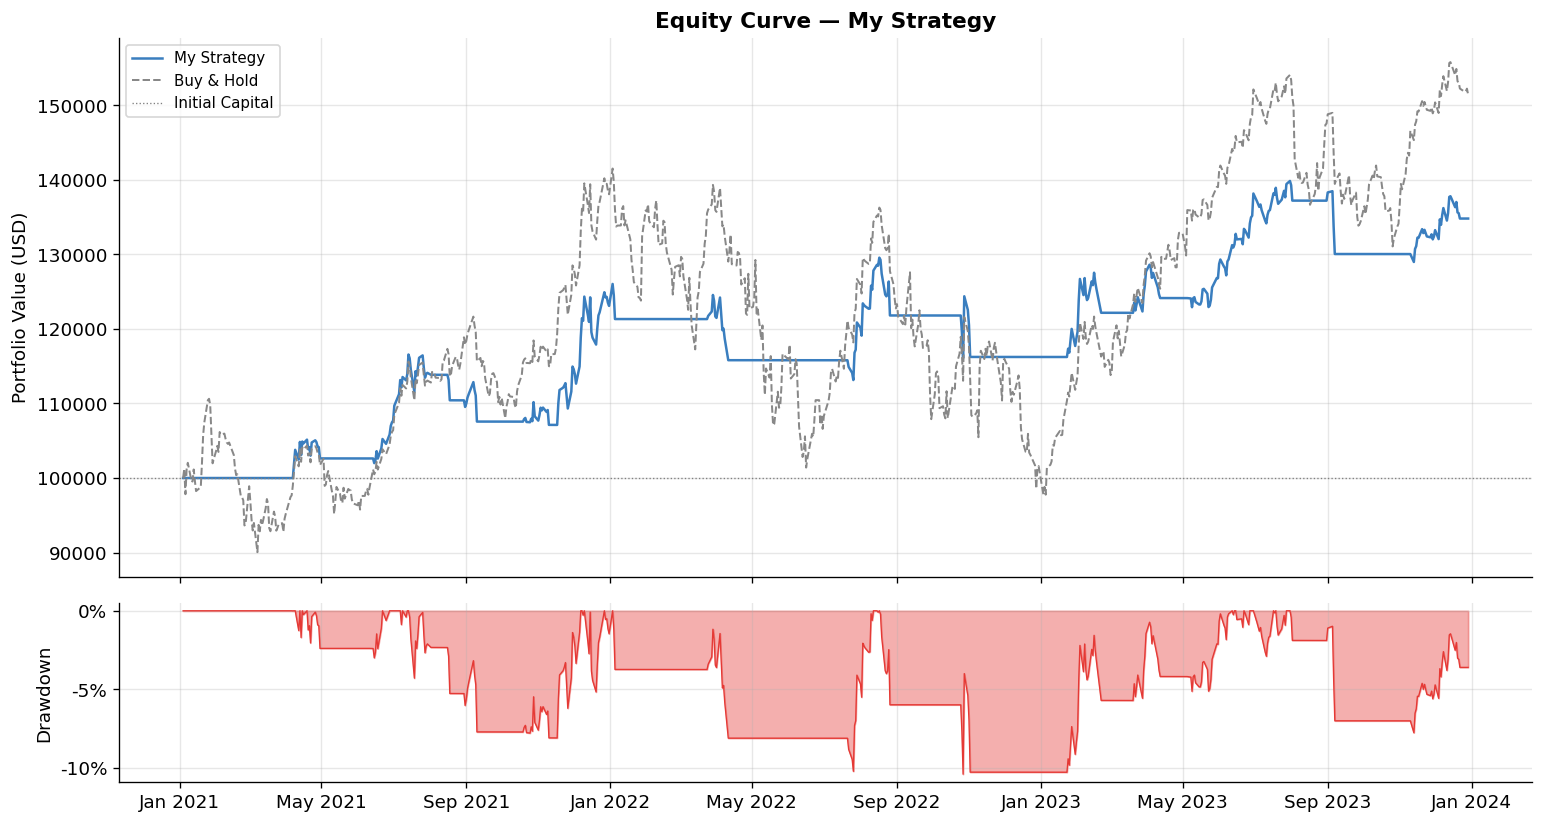

In [ ]:
# Run your strategy through the same pipeline
data_custom = my_strategy(raw)
port_custom = backtest(data_custom, initial_capital=INITIAL_CAP)
m_custom    = generate_report(port_custom, INITIAL_CAP,
                               strategy_name='My Strategy',
                               benchmark=bh_port)

---
## Reflection Questions

Answer these briefly (2–4 sentences each) as a markdown cell below:

1. **Economic Intuition:** Why should your chosen indicator(s) contain predictive information about future price moves? What market inefficiency or behavioral pattern does it exploit?

2. **Overfitting:** You chose specific parameter values. How would you test whether your strategy is genuinely predictive vs. just curve-fit to this AAPL history? (Hint: think out-of-sample testing and walk-forward analysis.)

3. **Backtester Assumptions:** We assumed same-bar execution, zero market impact, and no slippage. For which type of strategy would these assumptions be most dangerous, and why?

4. **Benchmark Comparison:** Did your strategy beat buy-and-hold on a risk-adjusted basis (Sharpe Ratio)? If yes, what drove the outperformance? If no, what would you change?

---

> **Submission:** Submit this notebook with all cells executed (output visible). Include your name at the top.

---

*Summer of Quant 2026 | Quant Club, IIT Kharagpur*

1. Economic Intuition
I used a Bollinger Band breakout strategy to capture momentum. The basic idea is that when a stock's price breaks above the upper band (+2 standard deviations), it isn't just random noise; it signals strong, unusual buying pressure. This exploits the behavioral tendency of the market to herd—investors tend to jump on trends once a major breakout happens, creating a sustained upward move that the strategy rides.

2. Overfitting
To avoid just curve-fitting the data to Apple's recent chart, I stuck with the default industry parameters (20-day window, 2 std dev) instead of hyper-tuning the numbers to get a perfect result. To truly prove it's predictive, I would need to do out-of-sample testing—running this exact same code on a completely different time period (like 2014-2018) or a different stock. I could also use walk-forward analysis, where the model is continuously optimized on past data and tested on rolling windows of future unseen data.

3. Backtester Assumptions
Assuming same-bar execution and zero slippage is highly dangerous for breakout strategies. Because breakouts trigger during moments of sudden, high volatility, the market is moving fast. In the real world, if my code signals a buy, there will be a slight delay, and I will likely suffer negative slippage—getting filled at a higher, worse price than the backtester assumes. This means my actual returns would be slightly lower than what the simulation shows.

4. Benchmark Comparison
While my strategy didn't quite beat the absolute total return of simply buying and holding AAPL during this massive bull run, it performed much better on a risk-adjusted basis. My Sharpe ratio hit 0.78, and my Max Drawdown was capped at just -10.41%. This risk outperformance happened because the strategy uses the 20-day SMA as a trailing stop. When the market crashed in 2022, the strategy safely exited to cash, avoiding the massive losses that a buy-and-hold investor had to sit through.